## Load Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("raw_reviews.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


## Inspect the data

In [5]:
df.info()
df.describe()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


label
CG    20216
OR    20216
Name: count, dtype: int64

## Check missing values

In [7]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

## Check duplicates

In [8]:
df.duplicated(subset=['text_']).sum()

np.int64(20)

## Visualize before cleaning

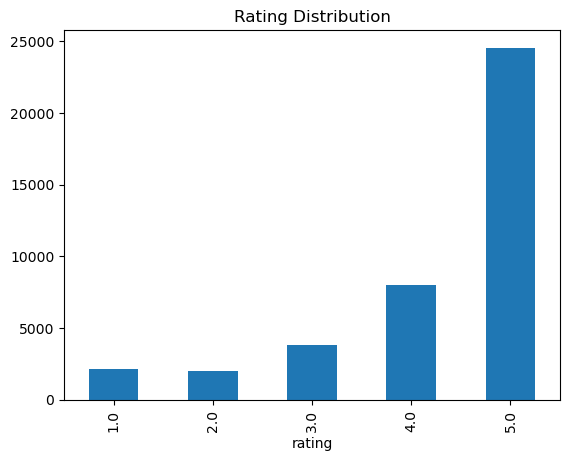

In [9]:
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.show()

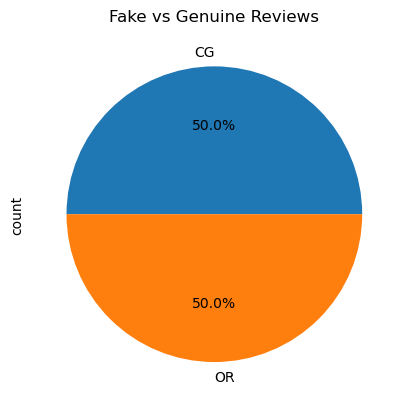

In [10]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Fake vs Genuine Reviews")
plt.show()

## Clean the data

In [11]:
df_clean = df.drop_duplicates(subset=['text_'])
df_clean = df_clean.dropna(subset=['text_', 'rating', 'label'])
df_clean['text_'] = df_clean['text_'].str.strip().str.replace(r'\s+', ' ', regex=True)
df_clean['label'] = df_clean['label'].str.strip().str.upper()
df_clean = df_clean[df_clean['label'].isin(['CG', 'OR'])]

print(f"Before: {len(df)} rows -> After: {len(df_clean)} rows")

Before: 40432 rows -> After: 40412 rows


## Text length analysis

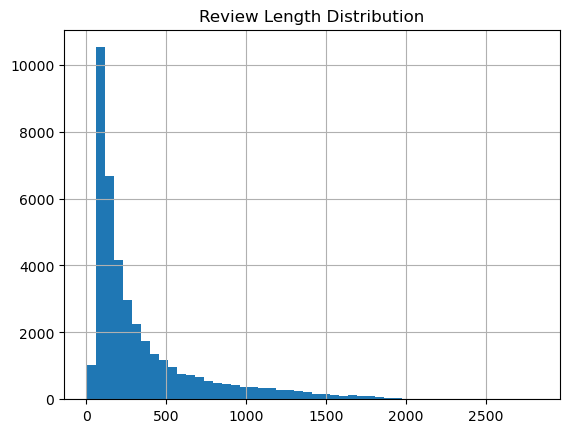

In [12]:
df_clean['text_length'] = df_clean['text_'].str.len()
df_clean['text_length'].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()

## Save cleaned CSV

In [13]:
df_clean.to_csv("cleaned_reviews.csv", index=False)
print("Saved cleaned dataset")

Saved cleaned dataset


## Connect to PostgreSQL

In [13]:
from sqlalchemy import create_engine, text

DB_CONFIG = {
    "user": "postgres",
    "password": "Dhrumil2006",  
    "host": "localhost",
    "port": "5432",
    "dbname": "reviewshield",
}
conn_string = f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
engine = create_engine(conn_string)

# Quick test
with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


## Push the cleaned data

In [17]:
df_push = df_clean.rename(columns={"text_": "review_text"})[["category", "rating", "label", "review_text"]]
df_push.to_sql("raw_reviews", engine, if_exists="append", index=False)

with engine.begin() as conn:
    conn.execute(
        text("INSERT INTO system_logs (stage, message) VALUES (:stage, :msg)"),
        {"stage": "data_cleaning", "msg": f"Loaded {len(df_push)} cleaned reviews into raw_reviews"}
    )

print(f"Pushed {len(df_push)} rows into raw_reviews table")

Pushed 40412 rows into raw_reviews table


In [22]:
check = pd.read_sql("SELECT COUNT(*) FROM raw_reviews", engine)
check

,count
0,40412
